In [1]:
import mysql.connector

# Create connection
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="1234",
    database="adventureworks"
)

# Check connection
if conn.is_connected():
    print("MySQL Connected Successfully")
else: 
    print("Failed to connect the database")

# Create cursor
cursor = conn.cursor()



cursor.close()
#conn.close()


MySQL Connected Successfully


True

In [2]:
print(conn.is_connected())

True


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
query = """
SELECT *
FROM works_productlookup

"""

df = pd.read_sql(query, conn)

print(df.head())

   ProductKey  ProductSubcategoryKey ProductSKU              ProductName  \
0         214                     31  HL-U509-R    Sport-100 Helmet, Red   
1         215                     31    HL-U509  Sport-100 Helmet, Black   
2         218                     23  SO-B909-M   Mountain Bike Socks, M   
3         219                     23  SO-B909-L   Mountain Bike Socks, L   
4         220                     31  HL-U509-B   Sport-100 Helmet, Blue   

             ModelName                                 ProductDescription  \
0            Sport-100  Universal fit, well-vented, lightweight , snap...   
1            Sport-100  Universal fit, well-vented, lightweight , snap...   
2  Mountain Bike Socks  Combination of natural and synthetic fibers st...   
3  Mountain Bike Socks  Combination of natural and synthetic fibers st...   
4            Sport-100  Universal fit, well-vented, lightweight , snap...   

  ProductColor ProductSize ProductStyle  ProductCost  ProductPrice  
0          

C:\Users\Radhika Kashid\AppData\Local\Temp\ipykernel_21080\499429363.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [29]:
top_products = (
    df.groupby('ProductName')['ProductPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

ProductName
Road-150 Red, 52           3578.27
Road-150 Red, 44           3578.27
Road-150 Red, 48           3578.27
Road-150 Red, 62           3578.27
Road-150 Red, 56           3578.27
Mountain-100 Silver, 38    3399.99
Mountain-100 Silver, 44    3399.99
Mountain-100 Silver, 42    3399.99
Mountain-100 Silver, 48    3399.99
Mountain-100 Black, 48     3374.99
Name: ProductPrice, dtype: float64


In [30]:
print(df.columns)

Index(['ProductKey', 'ProductSubcategoryKey', 'ProductSKU', 'ProductName',
       'ModelName', 'ProductDescription', 'ProductColor', 'ProductSize',
       'ProductStyle', 'ProductCost', 'ProductPrice'],
      dtype='object')


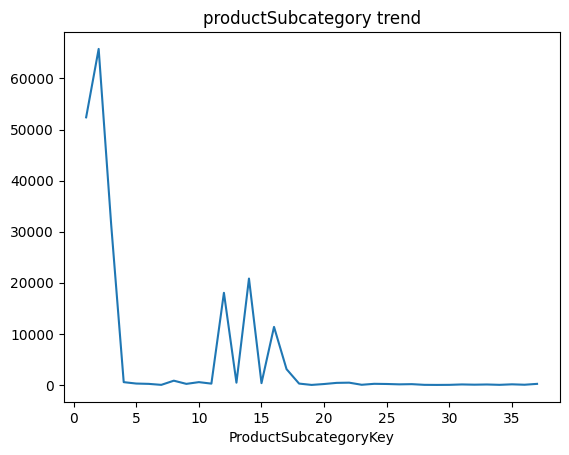

In [31]:
monthly_sales = df.groupby('ProductSubcategoryKey')['ProductPrice'].sum()

monthly_sales.plot(kind='line')
plt.title("productSubcategory trend")
plt.show()

In [12]:
top_products = (
    df.groupby('ProductName')['ProductCost']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

ProductName
Sport-100 Helmet, Red      13.0863
Sport-100 Helmet, Black    12.0278
Sport-100 Helmet, Blue     12.0278
Mountain Bike Socks, L      3.3963
Mountain Bike Socks, M      3.3963
Name: ProductCost, dtype: float64


In [32]:
customer_sales = df.groupby('ProductKey')['ProductPrice'].sum()

customer_sales.describe()

count     293.000000
mean      714.437357
std       872.157258
min         2.290000
25%        63.500000
50%       333.420000
75%      1003.910000
max      3578.270000
Name: ProductPrice, dtype: float64

In [33]:
Total_Profit = df['ProductPrice'].sum() - df['ProductCost'].sum()
print(Total_Profit)

88127.46979999998


In [34]:
df['Profit'] = df['ProductPrice']- df['ProductCost']

In [35]:
df['ProfitMargin'] = (
    df['Profit'] / df['ProductPrice']
) * 100

In [36]:
print(df['ProfitMargin'])

0      62.599886
1      64.250004
2      64.249474
3      64.249474
4      64.250004
         ...    
288    55.599960
289    55.599967
290    36.360007
291    36.360007
292    36.360007
Name: ProfitMargin, Length: 293, dtype: float64


In [37]:
assert df.isnull().sum().sum() == 0

In [39]:
invalid_sales = df[df['ProductPrice'] < 0]

In [40]:
duplicates = df[df.duplicated()]

In [41]:
print(conn.is_connected())


True


In [ ]:

df.to_csv(
    r'C:\Users\Radhika Kashid\OneDrive\Documents\DSA_End to end\PythonCleanedData\productLookup.csv',
    index=False
)

In [46]:
conn.close()